# Statistical Foundations for QC Problem Set
## General Set-up and Imports


In [12]:
%matplotlib inline

import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, hypergeom, poisson, norm, t, chi2, probplot, ttest_1samp


def add_caption(fig, caption):
    fig.subplots_adjust(bottom=0.22)
    fig.text(0.5, 0.02, caption, ha="center", va="bottom", fontsize=9)


## Problem 1 

For $X\sim\mathrm{Binomial}(20,p)$, the acceptance probability is $P_a=P(X\leq 1)$. 
Plot the curve and compare the supplied hand-computed values with SciPy. 
The comparison uses an absolute tolerance of $10^{-6}$.

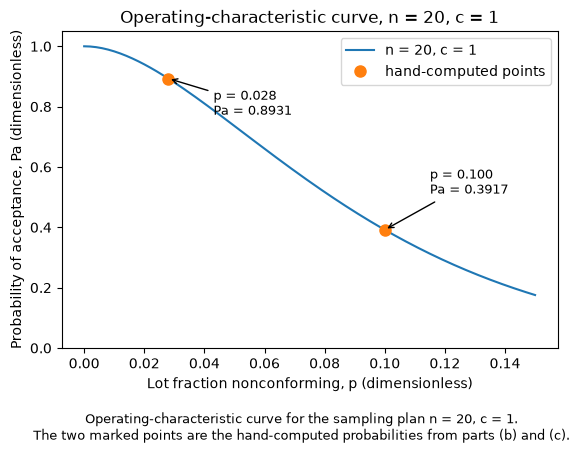

p = 0.028
    hand   = 0.893136
    Python = 0.893136
    agree? True

p = 0.100
    hand   = 0.391747
    Python = 0.391747
    agree? True



In [13]:
def add_caption(fig, caption):
    fig.subplots_adjust(bottom=0.22)
    fig.text(0.5, 0.02, caption, ha="center", va="bottom", fontsize=9)


# input parameters
n_plan = 20
c_plan = 1
# sweep p from 0 to 0.15
p_grid = np.linspace(0.0, 0.15, 151)
# acceptance probability for each p value
pa_grid = binom.cdf(c_plan, n_plan, p_grid)
# p1&p2 from hand calculations
p_marks = [0.028, 0.10]
# acceptance from hand calculations
pa_hand = [0.893136, 0.391747]
# compute same two points
pa_python = [binom.cdf(c_plan, n_plan, p) for p in p_marks]
# generate figure
fig, ax = plt.subplots()
# plot the oc curve
ax.plot(p_grid, pa_grid, label=f"n = {n_plan}, c = {c_plan}")
# plot hand calculation points
ax.plot(p_marks, pa_hand, "o", markersize=8, label="hand-computed points")

# locations for annotations
offsets = [(0.015, -0.12), (0.015, 0.12)]
# label each point
for (p, pa), (dx, dy) in zip(zip(p_marks, pa_hand), offsets):
    ax.annotate(
        f"p = {p:.3f}\nPa = {pa:.4f}",
        xy=(p, pa),
        xytext=(p + dx, pa + dy),
        arrowprops=dict(arrowstyle="->", lw=1.0),
        fontsize=9
    )
# label the axes
ax.set_xlabel("Lot fraction nonconforming, p (dimensionless)")
ax.set_ylabel("Probability of acceptance, Pa (dimensionless)")
# set graph title
ax.set_title("Operating-characteristic curve, n = 20, c = 1")
# set vertical axis limits
ax.set_ylim(0, 1.05)
# add legend
ax.legend(loc="upper right")
# add caption 
add_caption(
    fig,
    "Operating-characteristic curve for the sampling plan n = 20, c = 1.\n"
    "The two marked points are the hand-computed probabilities from parts (b) and (c)."
)
# display graph
plt.show()
# confirm the hand calculation and python values agree with each other
for p, hand, python_value in zip(p_marks, pa_hand, pa_python):
    print(f"p = {p:.3f}")
    print(f"    hand   = {hand:.6f}")
    print(f"    Python = {python_value:.6f}")
    print(f"    agree? {np.isclose(hand, python_value, atol=1e-6)}")
    print()


## Problem 2

Draw 5 units without replacement from a lot, containing 12% nonconforming units. 
Compare the exact probability of zero nonconforming units with $(1-0.12)^5$. 
Relative error is the absolute difference divided by the exact probability.

In [14]:
# parameters
n_draw = 5
frac = 0.12

# binomial approximation
# p = D/N stays fixed at 0.12
approx = (1 - frac) ** n_draw

# table headings
print(f"{'N':>6} {'n/N':>10} {'hypergeom':>12} "
      f"{'binomial':>12} {'rel err':>10}")

# sweep through 4 lot sizes
for N_lot in (25, 50, 150, 1000):

 # number of nonconforming units
 # D/N = 0.12
D_bad = int(round(frac * N_lot))

 # exact hypergeometric probability of finding 0 nonconforming units
exact = hypergeom.pmf(0, M=N_lot, n=D_bad, N=n_draw)

# absolute difference btn approximation and exact 
abs_err = abs(approx - exact)

# relative approximation error
rel_err = abs_err / exact

# print one row of the table
    print(f"{N_lot:>6} {n_draw/N_lot:>10.4f} "
          f"{exact:>12.6f} {approx:>12.6f} "
          f"{rel_err:>9.3%}")


IndentationError: expected an indented block after 'for' statement on line 14 (889320615.py, line 18)

## Problem 3 

With arrival rate $\lambda=5.6$ per hour, the count over $t$ hours has mean and variance $\lambda t$. Compare explicit formulas with SciPy for (b) at most two arrivals in 90 minutes, (c) moments over 2.5 hours, and (d) zero arrivals in 2.5 hours.

In [15]:
# set mean arrival rate lam =5.6
lam = 5.6
# convert 90 mins to hrs
t_90 = 90 / 60
# mean for the 90 mins window
mu_90 = lam * t_90
# calculate P(X <= 2) as P(X = 0) + P(X = 1) + P(X = 2)
terms = [
    math.exp(-mu_90) * mu_90**k / math.factorial(k)
    for k in range(3)
]
hand_b = sum(terms)
# scipy calculation of P(X <= 2)
python_b = poisson.cdf(2, mu_90)

#2.5 hr window
#set t
t_25 = 2.5
#mean over 2.5 hours
mu_25 = lam * t_25
# hand calculation values
mean_hand = mu_25
sd_hand = math.sqrt(mu_25)
# scipy values
mean_python = poisson.mean(mu_25)
var_python = poisson.var(mu_25)
sd_python = math.sqrt(var_python)

# hand calculation P(X = 0)
hand_d = math.exp(-mu_25)
# scipy probability P(X = 0)
python_d = poisson.pmf(0, mu_25)


# print results and compare
print("(b): P(X <= 2) in 90 minutes")
print(f"hand calculation value  = {hand_b:.6f}")
print(f"python calculation value= {python_b:.6f}")
print(f"agree? {np.isclose(hand_b, python_b, atol=1e-9)}")
print()

print("(c): moments over 2.5 hours")
print(f"mean value by hand   = {mean_hand:.6f}")
print(f"mean value by Python = {mean_python:.6f}")
print(f"SD by hand     = {sd_hand:.6f}")
print(f"SD by Python   = {sd_python:.6f}")
print()

print("(d): P(X = 0) in 2.5 hours")
print(f"hand calculation   = {hand_d:.9f}")
print(f"Python = {python_d:.9f}")
print(f"agree? {np.isclose(hand_d, python_d, atol=1e-12)}")

(b): P(X <= 2) in 90 minutes
hand calculation value  = 0.010047
python calculation value= 0.010047
agree? True

(c): moments over 2.5 hours
mean value by hand   = 14.000000
mean value by Python = 14.000000
SD by hand     = 3.741657
SD by Python   = 3.741657

(d): P(X = 0) in 2.5 hours
hand calculation   = 0.000000832
Python = 0.000000832
agree? True


## Problem 4 

Individual voltage has standard deviation $0.020$ V and specification limits $4.95$ and $5.05$ V. 
Compare the centered mean $5.000$ V with a $0.020$ V upward shift. 
For independent observations, the mean of 9 readings has standard deviation $\sigma/\sqrt{9}$.

**Distinction:** A sample mean outside these limits is not the same event as an individual unit being nonconforming. The plotted distributions below both use the shifted mean.

(a): 
lower tail = 0.006210
upper tail = 0.006210
total      = 0.012419
ppm        = 12419.3

(b):
Lower tail = 0.000233
Upper tail = 0.066807
Total      = 0.067040
ppm        = 67039.8

(c): sample mean, n = 9
sigma_xbar = 0.006667 V
Lower tail = 4.3190063178e-26
Upper tail = 3.3976731247e-06
Total      = 3.3976731247e-06



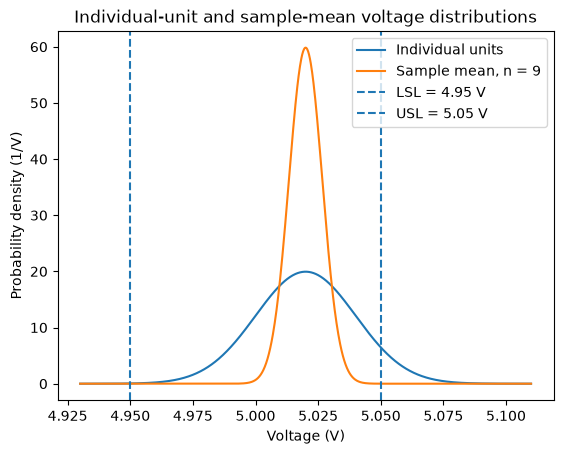

In [26]:
# process parameters
sigma = 0.020
LSL = 4.95
USL = 5.05
# set delta = 0.020 V
delta = 0.020
#centered process mean
mu_centered = 5.000
#centered process LSL and USL
lower_a = norm.cdf(LSL, loc=mu_centered, scale=sigma)
upper_a = norm.sf(USL, loc=mu_centered, scale=sigma)
#total probability
p_a = lower_a + upper_a

#shifted process mean
mu_shifted = 5.000 + delta
# shifted process upper & lower
lower_b = norm.cdf(LSL, loc=mu_shifted, scale=sigma)
upper_b = norm.sf(USL, loc=mu_shifted, scale=sigma)
#total probability
p_b = lower_b + upper_b

#sample mean, n = 9
n = 9
#sd
sigma_xbar = sigma / np.sqrt(n)
#lower and upper 
lower_c = norm.cdf(LSL, loc=mu_shifted, scale=sigma_xbar)
upper_c = norm.sf(USL, loc=mu_shifted, scale=sigma_xbar)
#total probability
p_c = lower_c + upper_c


# print exact probabilities
print("(a): ")
print(f"lower tail = {lower_a:.6f}")
print(f"upper tail = {upper_a:.6f}")
print(f"total      = {p_a:.6f}")
print(f"ppm        = {p_a * 1_000_000:.1f}")
print()

print("(b):")
print(f"Lower tail = {lower_b:.6f}")
print(f"Upper tail = {upper_b:.6f}")
print(f"Total      = {p_b:.6f}")
print(f"ppm        = {p_b * 1_000_000:.1f}")
print()

print("(c): sample mean, n = 9")
print(f"sigma_xbar = {sigma_xbar:.6f} V")
print(f"Lower tail = {lower_c:.10e}")
print(f"Upper tail = {upper_c:.10e}")
print(f"Total      = {p_c:.10e}")
print()


#create figure
x = np.linspace(4.93, 5.11, 1000)
individual_pdf = norm.pdf(x, loc=mu_shifted, scale=sigma)

xbar_pdf = norm.pdf(x,loc=mu_shifted,scale=sigma_xbar)

fig, ax = plt.subplots()
ax.plot(
    x,
    individual_pdf,
    label="Individual units"
)
ax.plot(
    x,
    xbar_pdf,
    label="Sample mean, n = 9"
)
ax.axvline(
    LSL,
    linestyle="--",
    label="LSL = 4.95 V"
)
ax.axvline(
    USL,
    linestyle="--",
    label="USL = 5.05 V"
)

ax.set_xlabel("Voltage (V)")
ax.set_ylabel("Probability density (1/V)")
ax.set_title(
    "Individual-unit and sample-mean voltage distributions"
)

ax.legend()


plt.show()

## Problem 5(a) 

Define the 16 observations once and retain their sample statistics for the remaining sections. 
The box plot and normal probability plot are diagnostics, not proof of normality. 
The subsequent exact $t$ and chi-square procedures assume independent observations from a normal population.

xbar = 10.259375 V
s    = 0.999049 V


/var/folders/rl/vvl7rwr17sz4149fyc6_x3980000gn/T/ipykernel_41344/2270233831.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0].boxplot(


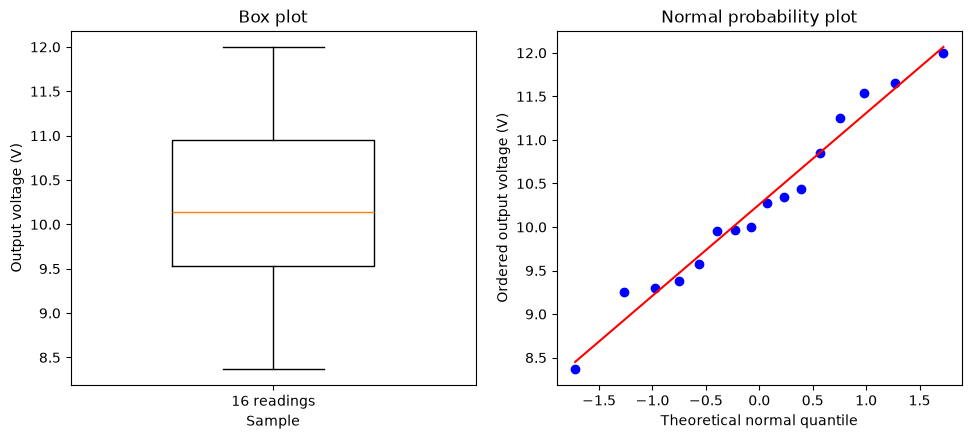

probability-plot r = 0.987696


In [31]:
#data
x = np.array([
    10.35, 9.30, 10.00, 9.96,
    11.65, 12.00, 11.25, 9.58,
    11.54, 9.95, 10.28, 8.37,
    10.44, 9.25, 9.38, 10.85
])
# define n, xbar variance and sd
n = len(x)

xbar = x.mean()
s = x.std(ddof=1)
s2 = s**2

print(f"xbar = {xbar:.6f} V")
print(f"s    = {s:.6f} V")

#figure axes and size
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
#boxplot components
axes[0].boxplot(
    x,
    vert=True,
    widths=0.5,
    tick_labels=["16 readings"]
)
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Output voltage (V)")
axes[0].set_title("Box plot")
result = probplot(x, dist="norm", plot=axes[1])
axes[1].set_xlabel("Theoretical normal quantile")
axes[1].set_ylabel("Ordered output voltage (V)")
axes[1].set_title("Normal probability plot")

plt.show()
#slope and intercept of the fitted line, and correlation coefficient
slope, intercept, r = result[1]
print(f"probability-plot r = {r:.6f}")

## Problem 5(b–c)

Use the problem constants for $d=9$: $\mu_0=11.60$ V, $\sigma_0^2=2.80$ V$^2$, and $\alpha=0.05$.

For the two-sided test $H_0:\mu=\mu_0$, compute
$$t_0=\frac{\bar{x}-\mu_0}{s/\sqrt{n}}.$$
The 95% confidence interval is $\bar{x}\pm t_{1-\alpha/2,n-1}s/\sqrt{n}$.

In [35]:
# data
x = np.array([
    10.35, 9.30, 10.00, 9.96,
    11.65, 12.00, 11.25, 9.58,
    11.54, 9.95, 10.28, 8.37,
    10.44, 9.25, 9.38, 10.85
])

# parameters
mu_0 = 11.60
var_0 = 2.80
alpha = 0.05

# sample stats
n = len(x)
xbar = x.mean()
s = x.std(ddof=1)
s2 = s**2
se = s / math.sqrt(n)


# (b) one sample ttest
# set t_0, t_crit, p_value
t_0 = (xbar - mu_0) / se
t_crit = t.ppf(1 - alpha / 2, n - 1)
p_value = 2 * t.sf(abs(t_0), n - 1)

print("(b)")
print(f"t_0     = {t_0:.6f}")
print(f"t_crit  = {t_crit:.6f}")
print(f"p-value = {p_value:.8f}")
print(
    "decision =",
    "reject H0" if abs(t_0) > t_crit
    else "fail to reject H0"
)
print()

# (c) 95% ci on mu
#set half_width and ci_mu in relation to t_crit and se
half_width = t_crit * se
ci_mu = (
    xbar - half_width,
    xbar + half_width
)

print("(c)")
print(
    f"95% CI on mu = "
    f"({ci_mu[0]:.6f}, {ci_mu[1]:.6f}) V"
)
print()

(b)
t_0     = -5.367603
t_crit  = 2.131450
p-value = 0.00007834
decision = reject H0

(c)
95% CI on mu = (9.727019, 10.791731) V



## Problem 5(d–e)

For $H_0:\sigma^2=2.80$ V$^2$, compare $(n-1)s^2/\sigma_0^2$ with the lower and upper chi-square critical values. 
Invert those quantiles for the two-sided variance interval, then take square roots for the interval on $\sigma$.

The **one-sided 95% upper bound** uses the lower $\alpha$ quantile, not the lower $\alpha/2$ quantile used by the two-sided interval.

In [ ]:
# (d) Chi-square variance test
#define chi2_0, chi2_lower, chi2_upper
chi2_0 = (n - 1) * s2 / var_0
chi2_lower = chi2.ppf(
    alpha / 2,
    n - 1
)
chi2_upper = chi2.ppf(
    1 - alpha / 2,
    n - 1
)
print("(d)")
print(f"chi2_0     = {chi2_0:.6f}")
print(f"lower crit = {chi2_lower:.6f}")
print(f"upper crit = {chi2_upper:.6f}")
print(
    "decision =",
    "reject H0"
    if (
        chi2_0 < chi2_lower
        or chi2_0 > chi2_upper
    )
    else "fail to reject H0"
)
print()

# (e) 95% CI on sigma
#define numerator, var_lower, var_upper, sigma_ci
numerator = (n - 1) * s2
var_lower = numerator / chi2_upper
var_upper = numerator / chi2_lower
sigma_ci = (
    math.sqrt(var_lower),
    math.sqrt(var_upper)
)

print("(e)")
print(
    f"95% CI on sigma = "
    f"({sigma_ci[0]:.6f}, "
    f"{sigma_ci[1]:.6f}) V"
)

# 95% one-sided upper bound
#define chi2_one_sided
chi2_one_sided = chi2.ppf(
    alpha,
    n - 1
)
#since test is one sided, only need to define upperbound for var and sigma
var_upper_bound = (numerator / chi2_one_sided)
sigma_upper_bound = math.sqrt(var_upper_bound)

print(
    f"95% upper bound on sigma = "
    f"{sigma_upper_bound:.6f} V"
)
print()

Part (d): two-sided variance test
chi2_0     = 5.346962
lower crit = 6.262138
upper crit = 27.488393
decision = reject H0

Part (e)
95% CI on variance = (0.544648, 2.390796) V²
95% CI on sigma = (0.738003, 1.546220) V
95% one-sided upper bound on sigma = 1.435939 V


## Problem 5 — Test–confidence interval correspondence

Set $\alpha^*$ equal to the observed two-sided mean-test p-value. The corresponding interval has $\mu_0$ at an endpoint (up to numerical precision). Use the inverse survival function for a stable tail calculation.

This is a **data-dependent boundary demonstration**, separate from the fixed 95% confidence interval above; it is not a new prespecified confidence procedure.

In [ ]:
alpha_star = p_value
t_star = t.isf(alpha_star / 2, df_voltage)
ci_star = (
    xbar_voltage - t_star * se_voltage,
    xbar_voltage + t_star * se_voltage,
)
print("Test / CI correspondence")
print(f"alpha* = p-value = {alpha_star:.10f}")
print(f"confidence level = {100 * (1 - alpha_star):.6f}%")
print(f"CI at alpha* = ({ci_star[0]:.8f}, {ci_star[1]:.8f}) V")
print(f"mu_0 = {mu_0:.8f} V")
at_endpoint = np.any(np.isclose(ci_star, mu_0, rtol=0, atol=1e-8))
print(f"mu_0 lies at a CI endpoint? {at_endpoint}")
assert at_endpoint, "The test/CI boundary check failed."


Test / CI correspondence
alpha* = p-value = 0.0000783375
confidence level = 99.992166%
CI at alpha* = (8.91875000, 11.60000000) V
mu_0 = 11.60000000 V
mu_0 lies at a CI endpoint? True
